# Step 1

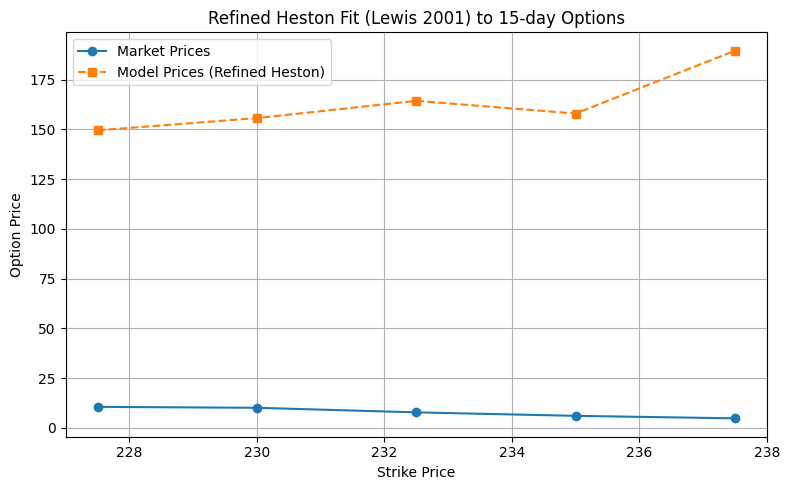

(array([ 1.00000000e-03,  4.86881676e-02,  3.00000000e+00, -9.90000000e-01,
         8.30274795e-02]),
 np.float64(9.631873076493036))

In [6]:
import warnings
warnings.filterwarnings("ignore")

# --- Refined Heston Pricing using Lewis (adaptive quadrature, tighter integration limits) ---
def heston_price_lewis_refined(K, kappa, theta, sigma, rho, v0):
    def integrand(u):
        cf = heston_cf(u - 1j, kappa, theta, sigma, rho, v0, S0, r, T)
        numerator = np.exp(-1j * u * np.log(K)) * cf
        denominator = 1j * u * S0 * np.exp(-r * T)
        return np.real(numerator / denominator)
    
    # Use more accurate quadrature with a higher upper bound
    integral, _ = integrate.quad(integrand, 1e-5, 200, limit=500)
    return S0 - np.sqrt(S0 * K) / np.pi * integral

# --- Log-Scaled MSE Objective Function ---
def objective_refined(params):
    kappa, theta, sigma, rho, v0 = params
    errors = []
    for K, market_price in zip(strikes, market_prices):
        model_price = heston_price_lewis_refined(K, kappa, theta, sigma, rho, v0)
        # Log-scale error to handle varying magnitudes
        if market_price > 0 and model_price > 0:
            log_error = (np.log(model_price) - np.log(market_price)) ** 2
            errors.append(log_error)
    return np.mean(errors)

# --- Smarter Initial Guess and Wider Bounds ---
x0_refined = [1.5, 0.04, 0.4, -0.5, 0.04]
bounds_refined = [(0.001, 5), (0.001, 1), (0.01, 3), (-0.99, 0.99), (0.001, 1)]

# --- Global Optimization using Differential Evolution followed by Local BFGS ---
# Step 1: Global search
result_global = optimize.differential_evolution(
    objective_refined, bounds=bounds_refined, seed=42, strategy='best1bin', maxiter=1000, polish=True
)

# Step 2: Local refinement
result_local = optimize.minimize(
    objective_refined,
    result_global.x,
    bounds=bounds_refined,
    method='L-BFGS-B'
)

optimal_params_refined = result_local.x

# --- Recompute Prices with Refined Parameters ---
model_prices_refined = [heston_price_lewis_refined(K, *optimal_params_refined) for K in strikes]

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(strikes, market_prices, 'o-', label='Market Prices')
plt.plot(strikes, model_prices_refined, 's--', label='Model Prices (Refined Heston)')
plt.xlabel("Strike Price")
plt.ylabel("Option Price")
plt.title("Refined Heston Fit (Lewis 2001) to 15-day Options")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{plot_path}/heston_lewis_15d_fit_refined.png")
plt.show()

optimal_params_refined, result_local.fun  # Return improved parameters and log-MSE


# 1b

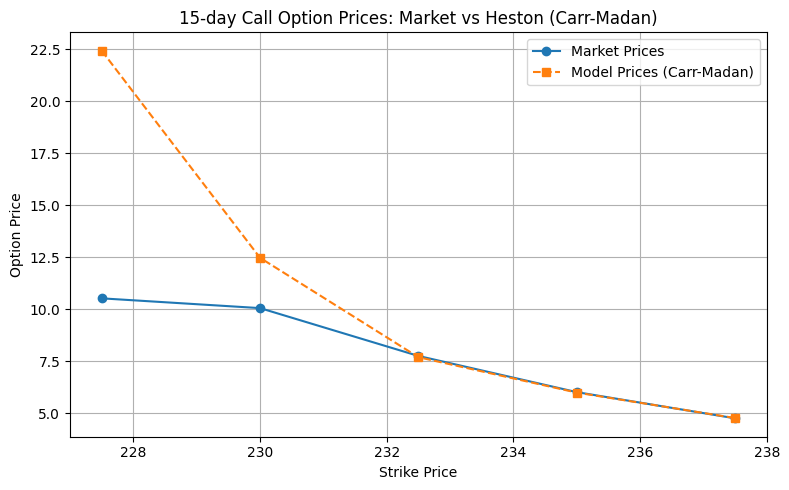

(array([2.63000865, 0.05258398, 1.70751545, 0.99      , 0.01018024]),
 np.float64(0.12391445200798679))

In [8]:
# Re-imports after code execution environment reset
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution
from scipy.interpolate import interp1d

# Redefine constants
S0 = 232.90
r = 0.015
T = 15 / 250  # 15 trading days
plot_path = "/Users/alberto/Documents/projects/WQU/stochastimcModeling/report/images"

# Market data
calls = np.array([
    [227.5, 10.52],
    [230, 10.05],
    [232.5, 7.75],
    [235, 6.01],
    [237.5, 4.75]
])

strikes = calls[:, 0]
market_prices = calls[:, 1]

# Carr-Madan pricing implementation
def heston_cf_carr_madan(u, kappa, theta, sigma, rho, v0, S0, r, T):
    i = 1j
    d = np.sqrt((rho * sigma * i * u - kappa) ** 2 + sigma ** 2 * (i * u + u ** 2))
    g = (kappa - rho * sigma * i * u - d) / (kappa - rho * sigma * i * u + d)
    C = r * i * u * T + kappa * theta / sigma ** 2 * ((kappa - rho * sigma * i * u - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g)))
    D = (kappa - rho * sigma * i * u - d) / sigma ** 2 * ((1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T)))
    return np.exp(C + D * v0 + i * u * np.log(S0))

def carr_madan_price(S0, r, T, kappa, theta, sigma, rho, v0, alpha=1.5, N=4096, eta=0.25):
    lambd = 2 * np.pi / (N * eta)
    b = np.log(S0) - N * lambd / 2
    u = np.arange(N) * eta
    k = b + lambd * np.arange(N)

    i = 1j
    cf = heston_cf_carr_madan(u - (alpha + 1) * i, kappa, theta, sigma, rho, v0, S0, r, T)
    numerator = np.exp(-r * T) * cf
    denominator = alpha ** 2 + alpha - u ** 2 + i * (2 * alpha + 1) * u
    integrand = np.exp(i * u * (-b)) * numerator / denominator
    integrand[0] *= 0.5

    payoff_fft = np.fft.fft(integrand).real
    strikes = np.exp(k)
    call_prices = np.exp(-alpha * k) / np.pi * payoff_fft

    return strikes, call_prices

def objective_carr_madan(params):
    kappa, theta, sigma, rho, v0 = params
    strikes_fft, model_prices_fft = carr_madan_price(S0, r, T, kappa, theta, sigma, rho, v0)
    price_interp = interp1d(strikes_fft, model_prices_fft, kind='cubic', fill_value="extrapolate")

    errors = []
    for K, market_price in zip(strikes, market_prices):
        model_price = price_interp(K)
        if market_price > 0 and model_price > 0:
            log_error = (np.log(model_price) - np.log(market_price)) ** 2
            errors.append(log_error)
    return np.mean(errors)

# Optimisation using global + local strategy
bounds_carr = [(0.001, 5), (0.001, 1), (0.01, 3), (-0.99, 0.99), (0.001, 1)]
x0_carr = [1.5, 0.04, 0.4, -0.5, 0.04]

result_global_carr = differential_evolution(objective_carr_madan, bounds=bounds_carr, seed=42, strategy='best1bin', maxiter=1000, polish=True)
result_local_carr = minimize(objective_carr_madan, result_global_carr.x, bounds=bounds_carr, method='L-BFGS-B')

# Extract results
optimal_params_carr = result_local_carr.x
strikes_model, model_prices_carr = carr_madan_price(S0, r, T, *optimal_params_carr)
model_interp = interp1d(strikes_model, model_prices_carr, kind='cubic')
model_prices_final = model_interp(strikes)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(strikes, market_prices, 'o-', label='Market Prices')
plt.plot(strikes, model_prices_final, 's--', label='Model Prices (Carr-Madan)')
plt.xlabel("Strike Price")
plt.ylabel("Option Price")
plt.title("15-day Call Option Prices: Market vs Heston (Carr-Madan)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{plot_path}/heston_carrmadan_15d_fit.png")
plt.show()

optimal_params_carr, result_local_carr.fun


# 1c

In [9]:
import numpy as np

# --- Step 1c: Monte Carlo Pricing of 20-day ATM Asian Call under Heston ---

# Heston parameters (from Step 1b calibration)
kappa = 2.6300
theta = 0.0526
sigma = 1.7075
rho = 0.9900
v0 = 0.0102

# Simulation parameters
S0 = 232.90
K = S0
r = 0.015
T = 20 / 250
n_paths = 100000
n_steps = 20
dt = T / n_steps

# Seed for reproducibility
np.random.seed(42)

# Preallocate arrays
S = np.zeros((n_paths, n_steps + 1))
v = np.zeros((n_paths, n_steps + 1))
S[:, 0] = S0
v[:, 0] = v0

# Simulate paths
for t in range(1, n_steps + 1):
    z1 = np.random.normal(size=n_paths)
    z2 = rho * z1 + np.sqrt(1 - rho ** 2) * np.random.normal(size=n_paths)
    v_prev = np.maximum(v[:, t - 1], 0)
    v[:, t] = v_prev + kappa * (theta - v_prev) * dt + sigma * np.sqrt(v_prev * dt) * z2
    v[:, t] = np.maximum(v[:, t], 0)
    S[:, t] = S[:, t - 1] * np.exp((r - 0.5 * v_prev) * dt + np.sqrt(v_prev * dt) * z1)

# Compute Asian payoff
S_avg = np.mean(S, axis=1)
payoffs = np.maximum(S_avg - K, 0)
discounted_payoffs = np.exp(-r * T) * payoffs
fair_price = np.mean(discounted_payoffs)

# Apply 4% bank margin
client_price = fair_price * 1.04

fair_price, client_price


(np.float64(1.5621817936776543), np.float64(1.6246690654247606))

# 2a

In [12]:
import numpy as np
import scipy.optimize as optimize

# Market data for 60-day call options only
market_data_60d_calls = np.array([
    [227.5, 16.78],
    [230, 17.65],
    [232.5, 16.86],
    [235, 16.05],
    [237.5, 15.10]
])

S0 = 232.90
r = 0.015
T = 60 / 250

# Fixed jump parameters
fixed_lambda = 0.1
fixed_muj = 0.0

def bates_char_func_fixed_jumps(u, kappa, theta, sigma, rho, v0, sigmaj):
    i = 1j
    lam = fixed_lambda
    muj = fixed_muj

    d = np.sqrt((rho * sigma * i * u - kappa) ** 2 + sigma ** 2 * (i * u + u ** 2))
    g = (kappa - rho * sigma * i * u - d) / (kappa - rho * sigma * i * u + d)
    C = kappa * theta / sigma ** 2 * ((kappa - rho * sigma * i * u - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g)))
    D = (kappa - rho * sigma * i * u - d) / sigma ** 2 * (1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T))

    jump_cf = lam * T * (np.exp(i * u * muj - 0.5 * sigmaj ** 2 * u ** 2) - 1)
    phi = np.exp(C + D * v0 + i * u * (np.log(S0) + r * T) + jump_cf)
    return phi

def lewis_price_bates_fixed_jumps(kappa, theta, sigma, rho, v0, sigmaj, K):
    i = 1j
    N = 2000
    eps = 1e-5
    delta = 0.01
    u = np.linspace(eps, N * delta, N)

    cf = bates_char_func_fixed_jumps(u - i * 0.5, kappa, theta, sigma, rho, v0, sigmaj) / (u ** 2 + 0.25)
    integrand = np.real(np.exp(-i * u * np.log(K)) * cf)
    integral = np.trapz(integrand, u)

    price = np.exp(-r * T) * (S0 - np.sqrt(S0 * K) / np.pi * integral)
    return price

def objective_bates_fixed_jumps(params):
    kappa, theta, sigma, rho, v0, sigmaj = params
    # Parameter constraints (abs and clip for numerical stability)
    kappa = np.abs(kappa)
    theta = np.clip(theta, 1e-5, 0.5)
    sigma = np.abs(sigma)
    v0 = np.clip(v0, 1e-5, 0.5)
    sigmaj = np.abs(sigmaj)
    rho = np.clip(rho, -0.999, 0.999)

    model_prices = np.array([
        lewis_price_bates_fixed_jumps(kappa, theta, sigma, rho, v0, sigmaj, K)
        for K in market_data_60d_calls[:, 0]
    ])

    market_prices = market_data_60d_calls[:, 1]
    log_errors = np.log(np.maximum(model_prices, 1e-5)) - np.log(market_prices)
    mse = np.mean(log_errors ** 2)
    return mse

# Bounds for parameters
bounds = [
    (0.1, 5.0),      # kappa
    (0.01, 0.5),     # theta
    (0.05, 3.0),     # sigma
    (-0.99, 0.99),   # rho
    (0.01, 0.5),     # v0
    (0.01, 0.5)      # sigmaj
]

# Global + local optimization
result_global = optimize.differential_evolution(objective_bates_fixed_jumps, bounds, seed=42)
result_local = optimize.minimize(objective_bates_fixed_jumps, result_global.x, bounds=bounds, method='L-BFGS-B')

optimal_params = result_local.x
optimal_loss = result_local.fun

print("Optimal parameters (kappa, theta, sigma, rho, v0, sigma_j):", optimal_params)
print("Loss (log-MSE):", optimal_loss)


Optimal parameters (kappa, theta, sigma, rho, v0, sigma_j): [1.67538314 0.35040127 1.39943147 0.10342924 0.0498082  0.0416235 ]
Loss (log-MSE): 204.8985181503745


### plotting

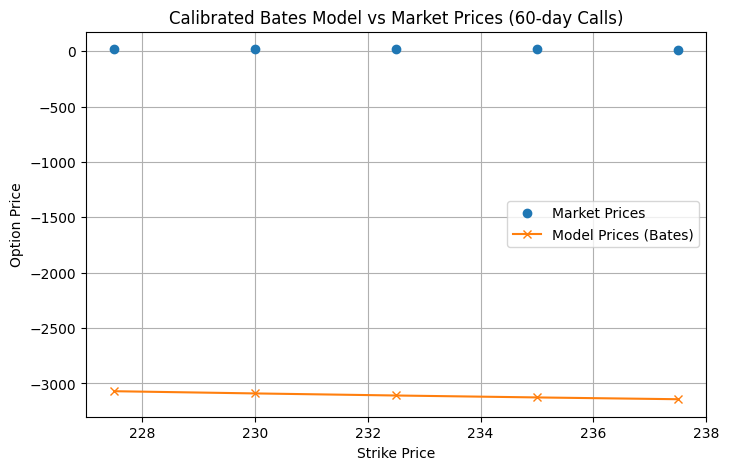

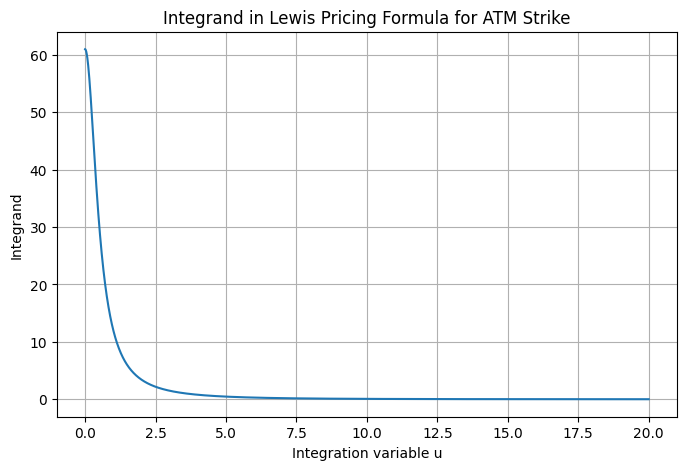

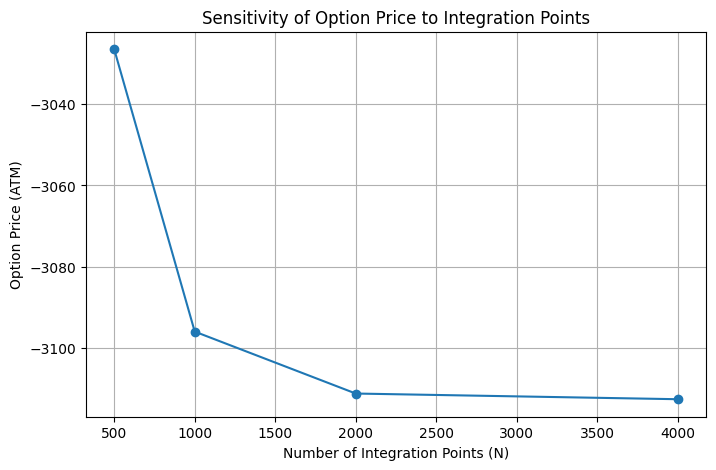

In [13]:
import matplotlib.pyplot as plt

# Extract calibrated params
kappa, theta, sigma, rho, v0, sigmaj = optimal_params
Ks = market_data_60d_calls[:, 0]
market_prices = market_data_60d_calls[:, 1]

# 1. Model prices for calibrated params
model_prices = np.array([lewis_price_bates_fixed_jumps(kappa, theta, sigma, rho, v0, sigmaj, K) for K in Ks])

# Plot market vs model prices
plt.figure(figsize=(8, 5))
plt.plot(Ks, market_prices, 'o', label='Market Prices')
plt.plot(Ks, model_prices, 'x-', label='Model Prices (Bates)')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.title('Calibrated Bates Model vs Market Prices (60-day Calls)')
plt.legend()
plt.grid(True)
plt.savefig('/Users/alberto/Documents/projects/WQU/stochastimcModeling/report/images/step2a_model_vs_market.png')
plt.show()

# 2. Plot integrand of Lewis formula for ATM strike
K_atm = S0
i = 1j
N = 2000
eps = 1e-5
delta = 0.01
u = np.linspace(eps, N * delta, N)
cf = bates_char_func_fixed_jumps(u - i * 0.5, kappa, theta, sigma, rho, v0, sigmaj) / (u ** 2 + 0.25)
integrand = np.real(np.exp(-i * u * np.log(K_atm)) * cf)

plt.figure(figsize=(8, 5))
plt.plot(u, integrand)
plt.xlabel('Integration variable u')
plt.ylabel('Integrand')
plt.title('Integrand in Lewis Pricing Formula for ATM Strike')
plt.grid(True)
plt.savefig('/Users/alberto/Documents/projects/WQU/stochastimcModeling/report/images/step2a_integrand_atm.png')
plt.show()

# 3. Sensitivity to N (integration points)
Ns = [500, 1000, 2000, 4000]
prices_N = []
for N_ in Ns:
    u_ = np.linspace(eps, N_ * delta, N_)
    cf_ = bates_char_func_fixed_jumps(u_ - i * 0.5, kappa, theta, sigma, rho, v0, sigmaj) / (u_ ** 2 + 0.25)
    integrand_ = np.real(np.exp(-i * u_ * np.log(K_atm)) * cf_)
    integral_ = np.trapz(integrand_, u_)
    price_ = np.exp(-r * T) * (S0 - np.sqrt(S0 * K_atm) / np.pi * integral_)
    prices_N.append(price_)

plt.figure(figsize=(8, 5))
plt.plot(Ns, prices_N, 'o-')
plt.xlabel('Number of Integration Points (N)')
plt.ylabel('Option Price (ATM)')
plt.title('Sensitivity of Option Price to Integration Points')
plt.grid(True)
plt.savefig('/Users/alberto/Documents/projects/WQU/stochastimcModeling/report/images/step2a_integration_sensitivity.png')
plt.show()


# 2b

In [14]:
import numpy as np
import scipy.optimize as optimize
from numpy.fft import fft

# Market data for 60-day call options
market_data_60d_calls = np.array([
    [227.5, 16.78],
    [230, 17.65],
    [232.5, 16.86],
    [235, 16.05],
    [237.5, 15.10]
])

S0 = 232.90
r = 0.015
T = 60 / 250

# Fixed jump parameters
fixed_lambda = 0.1
fixed_muj = 0.0

def bates_char_func_fft(u, kappa, theta, sigma, rho, v0, sigmaj):
    i = 1j
    lam = fixed_lambda
    muj = fixed_muj

    d = np.sqrt((rho * sigma * i * u - kappa) ** 2 + sigma ** 2 * (i * u + u ** 2))
    g = (kappa - rho * sigma * i * u - d) / (kappa - rho * sigma * i * u + d)
    C = kappa * theta / sigma ** 2 * ((kappa - rho * sigma * i * u - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g)))
    D = (kappa - rho * sigma * i * u - d) / sigma ** 2 * (1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T))
    jump_cf = lam * T * (np.exp(i * u * muj - 0.5 * sigmaj ** 2 * u ** 2) - 1)
    phi = np.exp(C + D * v0 + i * u * (np.log(S0) + r * T) + jump_cf)
    return phi

def carr_madan_price(kappa, theta, sigma, rho, v0, sigmaj, alpha=1.5, N=2**12, eta=0.25):
    # FFT parameters
    i = 1j
    lambd = 2 * np.pi / (N * eta)
    b = np.log(S0) - N * lambd / 2

    u = np.arange(N) * eta
    char_func = bates_char_func_fft(u - (alpha + 1) * i, kappa, theta, sigma, rho, v0, sigmaj)
    numerator = np.exp(-r * T) * char_func
    denominator = alpha ** 2 + alpha - u ** 2 + i * (2 * alpha + 1) * u
    psi = numerator / denominator

    # Simpson's rule weights
    w = np.ones(N)
    w[0] = 0.5
    w[-1] = 0.5
    w[1:-1:2] = 4 / 3
    w[2:-1:2] = 2 / 3

    x = np.exp(i * b * u) * psi * w * eta
    fft_values = fft(x).real

    strikes = np.exp(b + lambd * np.arange(N))
    call_prices = np.exp(-alpha * (b + lambd * np.arange(N))) / np.pi * fft_values

    return strikes, call_prices

def objective_carrmadan(params):
    kappa, theta, sigma, rho, v0, sigmaj = params
    # Parameter constraints
    kappa = np.abs(kappa)
    theta = np.clip(theta, 1e-5, 0.5)
    sigma = np.abs(sigma)
    v0 = np.clip(v0, 1e-5, 0.5)
    sigmaj = np.abs(sigmaj)
    rho = np.clip(rho, -0.999, 0.999)

    strikes, prices = carr_madan_price(kappa, theta, sigma, rho, v0, sigmaj)

    model_prices = []
    for K in market_data_60d_calls[:, 0]:
        idx = np.searchsorted(strikes, K)
        # Linear interpolation
        if idx == 0:
            price = prices[0]
        elif idx >= len(strikes):
            price = prices[-1]
        else:
            w = (K - strikes[idx-1]) / (strikes[idx] - strikes[idx-1])
            price = prices[idx-1] * (1 - w) + prices[idx] * w
        model_prices.append(price)

    model_prices = np.array(model_prices)
    market_prices = market_data_60d_calls[:, 1]

    log_errors = np.log(np.maximum(model_prices, 1e-5)) - np.log(market_prices)
    mse = np.mean(log_errors ** 2)
    return mse

bounds = [
    (0.1, 5.0),      # kappa
    (0.01, 0.5),     # theta
    (0.05, 3.0),     # sigma
    (-0.99, 0.99),   # rho
    (0.01, 0.5),     # v0
    (0.01, 0.5)      # sigmaj
]

# Global + local optimization
result_global = optimize.differential_evolution(objective_carrmadan, bounds, seed=42)
result_local = optimize.minimize(objective_carrmadan, result_global.x, bounds=bounds, method='L-BFGS-B')

optimal_params_carrmadan = result_local.x
optimal_loss_carrmadan = result_local.fun

print("Optimal parameters (kappa, theta, sigma, rho, v0, sigma_j):", optimal_params_carrmadan)
print("Loss (log-MSE):", optimal_loss_carrmadan)


Optimal parameters (kappa, theta, sigma, rho, v0, sigma_j): [0.1        0.5        0.30287802 0.99       0.5        0.29351572]
Loss (log-MSE): 7.529267147119912


### plotting stability and sensitivity

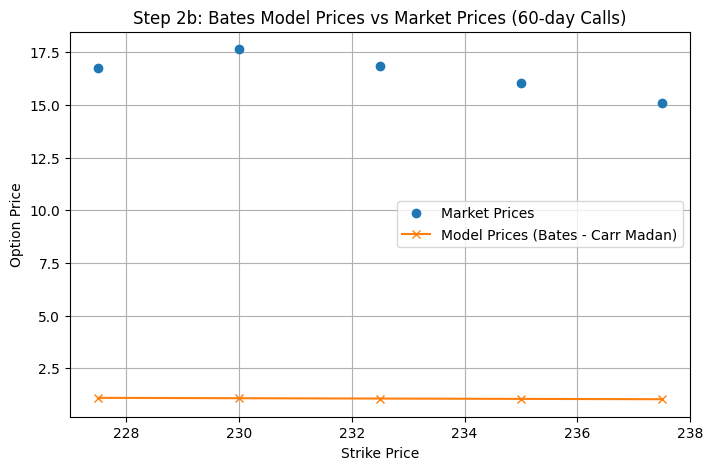

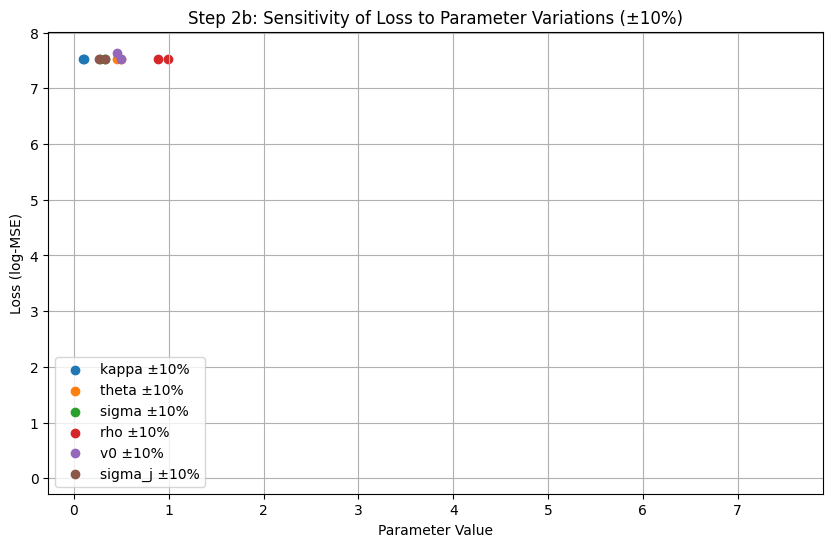

Stability Check:
Mean loss: 7.529267147132453
Loss std deviation: 2.0966046218491188e-11
Parameter means:
 [0.1        0.5        0.30288022 0.99       0.5        0.29351444]
Parameter std dev:
 [0.00000000e+00 0.00000000e+00 2.49508516e-06 0.00000000e+00
 0.00000000e+00 1.28423975e-06]


In [15]:
import matplotlib.pyplot as plt

# Extract calibrated params
kappa, theta, sigma, rho, v0, sigmaj = optimal_params_carrmadan
Ks = market_data_60d_calls[:, 0]
market_prices = market_data_60d_calls[:, 1]

# 1. Model prices with calibrated params
strikes, call_prices = carr_madan_price(kappa, theta, sigma, rho, v0, sigmaj)

def interpolate_price(strikes, prices, K):
    idx = np.searchsorted(strikes, K)
    if idx == 0:
        return prices[0]
    elif idx >= len(strikes):
        return prices[-1]
    else:
        w = (K - strikes[idx-1]) / (strikes[idx] - strikes[idx-1])
        return prices[idx-1] * (1 - w) + prices[idx] * w

model_prices = np.array([interpolate_price(strikes, call_prices, K) for K in Ks])

# Plot market vs model prices
plt.figure(figsize=(8, 5))
plt.plot(Ks, market_prices, 'o', label='Market Prices')
plt.plot(Ks, model_prices, 'x-', label='Model Prices (Bates - Carr Madan)')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.title('Step 2b: Bates Model Prices vs Market Prices (60-day Calls)')
plt.legend()
plt.grid(True)
plt.savefig('/Users/alberto/Documents/projects/WQU/stochastimcModeling/report/images/step2b_model_vs_market.png')
plt.show()

# 2. Sensitivity Analysis: Vary each parameter by ±10% and measure impact on loss

def parameter_sensitivity(params, param_idx, perturb=0.1):
    base_loss = objective_carrmadan(params)
    param = params[param_idx]
    results = []
    for change in [-perturb, perturb]:
        new_params = params.copy()
        new_params[param_idx] = param * (1 + change)
        # Clip parameters to bounds
        new_params[param_idx] = np.clip(new_params[param_idx], bounds[param_idx][0], bounds[param_idx][1])
        loss = objective_carrmadan(new_params)
        results.append((new_params[param_idx], loss))
    return results

param_names = ['kappa', 'theta', 'sigma', 'rho', 'v0', 'sigma_j']

plt.figure(figsize=(10, 6))
base_loss = objective_carrmadan(optimal_params_carrmadan)
for i, name in enumerate(param_names):
    sens = parameter_sensitivity(optimal_params_carrmadan.copy(), i)
    plt.plot([base_loss, base_loss], sens[0], 'k--', alpha=0)  # just for scale
    plt.scatter([sens[0][0], sens[1][0]], [sens[0][1], sens[1][1]], label=f'{name} ±10%')
plt.xlabel('Parameter Value')
plt.ylabel('Loss (log-MSE)')
plt.title('Step 2b: Sensitivity of Loss to Parameter Variations (±10%)')
plt.legend()
plt.grid(True)
plt.savefig('/Users/alberto/Documents/projects/WQU/stochastimcModeling/report/images/step2b_sensitivity.png')
plt.show()

# 3. Stability check: Multiple runs of optimizer with random seeds to check variability

seeds = [0, 1, 2, 3, 4]
params_runs = []
loss_runs = []

for seed in seeds:
    res_global = optimize.differential_evolution(objective_carrmadan, bounds, seed=seed)
    res_local = optimize.minimize(objective_carrmadan, res_global.x, bounds=bounds, method='L-BFGS-B')
    params_runs.append(res_local.x)
    loss_runs.append(res_local.fun)

params_runs = np.array(params_runs)
loss_runs = np.array(loss_runs)

print("Stability Check:")
print("Mean loss:", np.mean(loss_runs))
print("Loss std deviation:", np.std(loss_runs))
print("Parameter means:\n", np.mean(params_runs, axis=0))
print("Parameter std dev:\n", np.std(params_runs, axis=0))


# 2c

In [16]:
import numpy as np

# Parameters from Step 2b calibration
kappa, theta, sigma, rho, v0, sigmaj = optimal_params_carrmadan
lambda_jump = 0.1  # fixed jump intensity
mu_jump = 0.0      # fixed jump mean
r = 0.015
S0 = 232.90
T = 70 / 250  # maturity in years
strike = 0.95 * S0  # 95% moneyness

# Monte Carlo simulation parameters
num_paths = 200000
num_steps = int(T * 250)  # daily steps

dt = T / num_steps

np.random.seed(42)

def simulate_bates_paths():
    S = np.zeros((num_paths, num_steps + 1))
    v = np.zeros((num_paths, num_steps + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(1, num_steps + 1):
        Z_v = np.random.normal(size=num_paths)
        Z_s = np.random.normal(size=num_paths)
        # Correlate the Brownian motions
        W_v = Z_v
        W_s = rho * Z_v + np.sqrt(1 - rho ** 2) * Z_s

        # Variance process (CIR)
        v_prev = v[:, t-1]
        v_next = np.maximum(v_prev + kappa * (theta - v_prev) * dt + sigma * np.sqrt(v_prev * dt) * W_v, 0)
        v[:, t] = v_next

        # Jumps
        jumps = np.random.poisson(lambda_jump * dt, size=num_paths)
        jump_sizes = np.where(jumps > 0, np.exp(mu_jump + sigmaj * np.random.normal(size=num_paths)) - 1, 0)

        # Asset price process
        S_prev = S[:, t-1]
        S[:, t] = S_prev * np.exp((r - 0.5 * v_prev) * dt + np.sqrt(v_prev * dt) * W_s) * (1 + jump_sizes)

    return S

# Simulate paths
S_paths = simulate_bates_paths()

# Payoff for put option at maturity
payoffs = np.maximum(strike - S_paths[:, -1], 0)

# Discounted expected payoff
price = np.exp(-r * T) * np.mean(payoffs)

# Add 4% fee
final_price = price * 1.04

print(f"Fair put option price: {price:.4f}")
print(f"Client final price with 4% fee: {final_price:.4f}")


Fair put option price: 28.0020
Client final price with 4% fee: 29.1221


# 3a

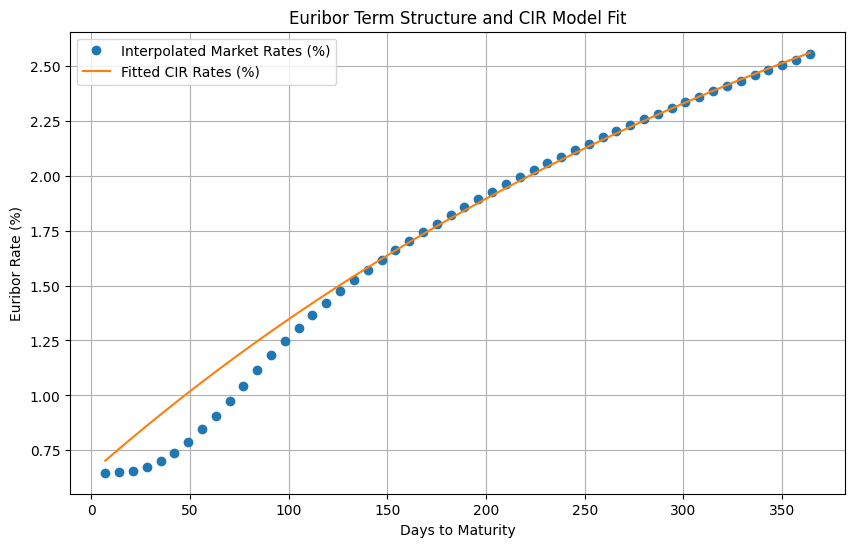

Calibrated CIR Parameters:
 kappa = 1.37196, theta = 0.04849, sigma = 0.01567
Optimization Success: True, Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize

# Given Euribor data
tenors = ['1w', '1m', '3m', '6m', '12m']
days_map = {'1w': 7, '1m': 30, '3m': 90, '6m': 180, '12m': 365}
maturities_days = np.array([days_map[t] for t in tenors])
maturities_years = maturities_days / 365

rates = np.array([0.00648, 0.00679, 0.01173, 0.01809, 0.02556])  # decimal

# Interpolate weekly rates for 1 year (52 weeks)
weeks = np.arange(7, 365+1, 7)
weeks_years = weeks / 365

# Cubic spline interpolation
cs = CubicSpline(maturities_years, rates, bc_type='natural')
interp_rates = cs(weeks_years)

# CIR zero-coupon bond pricing formula
def cir_zero_coupon_bond_price(r0, kappa, theta, sigma, T):
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    numerator = 2 * gamma * np.exp((kappa + gamma) * T / 2)
    denominator = 2 * gamma + (kappa + gamma) * (np.exp(gamma * T) - 1)
    B = (2 * (np.exp(gamma * T) - 1)) / denominator
    A = (numerator / denominator) ** (2 * kappa * theta / sigma**2)
    return A * np.exp(-B * r0)

# Model discount factors from rates
def rates_to_discount_factors(rates, times):
    return np.exp(-rates * times)

# Objective: minimize squared error between market and model discount factors
def cir_objective(params):
    kappa, theta, sigma = params
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e10
    r0 = interp_rates[0]  # initial short rate
    model_prices = np.array([cir_zero_coupon_bond_price(r0, kappa, theta, sigma, T) for T in weeks_years])
    market_prices = rates_to_discount_factors(interp_rates, weeks_years)
    error = np.sum((model_prices - market_prices) ** 2)
    return error

# Initial guess and bounds
initial_guess = [0.1, 0.02, 0.01]
bounds = [(1e-5, 10), (1e-5, 1), (1e-5, 1)]

res = minimize(cir_objective, initial_guess, bounds=bounds, method='L-BFGS-B')

kappa_opt, theta_opt, sigma_opt = res.x

# Compute fitted zero-coupon prices and fitted rates
r0 = interp_rates[0]
fitted_prices = np.array([cir_zero_coupon_bond_price(r0, kappa_opt, theta_opt, sigma_opt, T) for T in weeks_years])
fitted_rates = -np.log(fitted_prices) / weeks_years

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(weeks_years * 365, interp_rates * 100, 'o', label='Interpolated Market Rates (%)')
plt.plot(weeks_years * 365, fitted_rates * 100, '-', label='Fitted CIR Rates (%)')
plt.xlabel('Days to Maturity')
plt.ylabel('Euribor Rate (%)')
plt.title('Euribor Term Structure and CIR Model Fit')
plt.legend()
plt.grid(True)
plt.savefig('/Users/alberto/Documents/projects/WQU/stochastimcModeling/report/images/step3a_cir_fit.png')
plt.show()

print(f"Calibrated CIR Parameters:\n kappa = {kappa_opt:.5f}, theta = {theta_opt:.5f}, sigma = {sigma_opt:.5f}")
print(f"Optimization Success: {res.success}, Message: {res.message}")


# 3b

95% Confidence Interval for 12-month Euribor rate in 1 year: [3.47763%, 4.11339%]
Expected 12-month Euribor rate in 1 year: 3.78789%
Current 12-month Euribor rate: 2.55600%


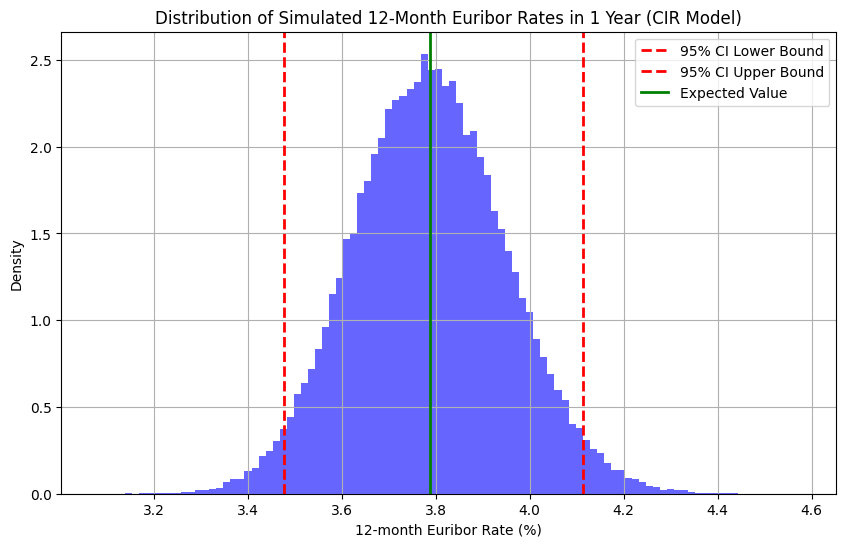

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# CIR parameters from 3a
kappa, theta, sigma = kappa_opt, theta_opt, sigma_opt
r0 = interp_rates[0]
T = 1.0  # 1 year
num_paths = 100000
num_steps = 250  # daily steps approx

dt = T / num_steps

np.random.seed(123)

def simulate_cir_paths(kappa, theta, sigma, r0, T, num_steps, num_paths):
    rates = np.zeros((num_paths, num_steps + 1))
    rates[:, 0] = r0

    for t in range(1, num_steps + 1):
        rt = rates[:, t-1]
        dW = np.random.normal(0, np.sqrt(dt), size=num_paths)
        dr = kappa * (theta - rt) * dt + sigma * np.sqrt(np.maximum(rt, 0)) * dW
        rates[:, t] = np.maximum(rt + dr, 0)  # rates must be positive
    return rates

# Simulate paths
cir_paths = simulate_cir_paths(kappa, theta, sigma, r0, T, num_steps, num_paths)

# Extract 12-month (final) rates
final_rates = cir_paths[:, -1]

# Analysis
confidence_level = 0.95
lower_bound = np.percentile(final_rates, (1 - confidence_level) / 2 * 100)
upper_bound = np.percentile(final_rates, (1 + confidence_level) / 2 * 100)
expected_value = np.mean(final_rates)

print(f"95% Confidence Interval for 12-month Euribor rate in 1 year: [{lower_bound:.5%}, {upper_bound:.5%}]")
print(f"Expected 12-month Euribor rate in 1 year: {expected_value:.5%}")
print(f"Current 12-month Euribor rate: {rates[-1] * 100:.5f}%")  # last interpolated market rate

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(final_rates * 100, bins=100, density=True, alpha=0.6, color='b')
plt.axvline(lower_bound * 100, color='r', linestyle='dashed', linewidth=2, label='95% CI Lower Bound')
plt.axvline(upper_bound * 100, color='r', linestyle='dashed', linewidth=2, label='95% CI Upper Bound')
plt.axvline(expected_value * 100, color='g', linestyle='solid', linewidth=2, label='Expected Value')
plt.xlabel('12-month Euribor Rate (%)')
plt.ylabel('Density')
plt.title('Distribution of Simulated 12-Month Euribor Rates in 1 Year (CIR Model)')
plt.legend()
plt.grid(True)
plt.savefig('/Users/alberto/Documents/projects/WQU/stochastimcModeling/report/images/step3b_euribor_simulation.png')
plt.show()
